# Task 7.2 Stock Price Prediction Using Time Series Forecasting

 ## 1. Load and Preprocess the Dataset

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("Stock_prices.csv")

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Handle missing values (fill with previous values)
df.fillna(method='ffill', inplace=True)

# Set Date as index
df.set_index('Date', inplace=True)

In [2]:
df.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,18766300,23.889999
2010-06-30,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2010-07-01,25.000000,25.92,20.270000,21.959999,8218800,21.959999
2010-07-02,23.000000,23.10,18.709999,19.200001,5139800,19.200001
2010-07-06,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [3]:
df.shape

(1692, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1692 entries, 2010-06-29 to 2017-03-17
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1692 non-null   float64
 1   High       1692 non-null   float64
 2   Low        1692 non-null   float64
 3   Close      1692 non-null   float64
 4   Volume     1692 non-null   int64  
 5   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 92.5 KB


In [5]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close'], dtype='object')

In [6]:
df.describe()

,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


## 2. Exploratory Data Analysis (EDA)

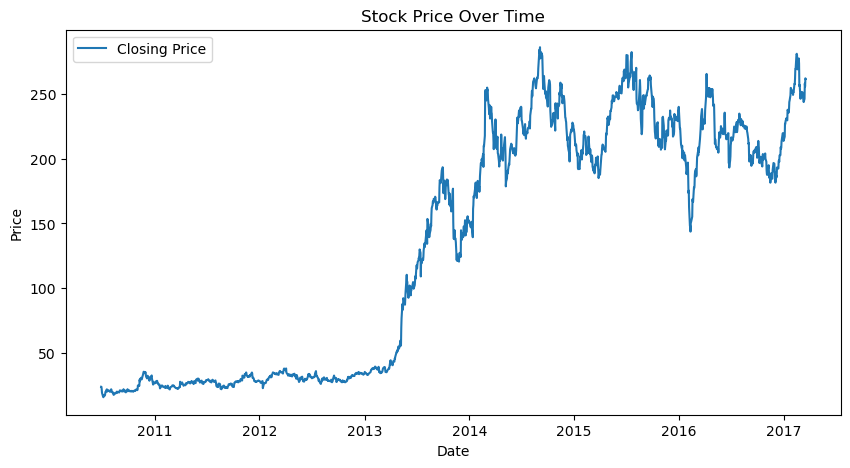

In [7]:
import matplotlib.pyplot as plt

# Plot closing price over time
plt.figure(figsize=(10,5))
plt.plot(df['Close'], label="Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price Over Time")
plt.legend()
plt.show()

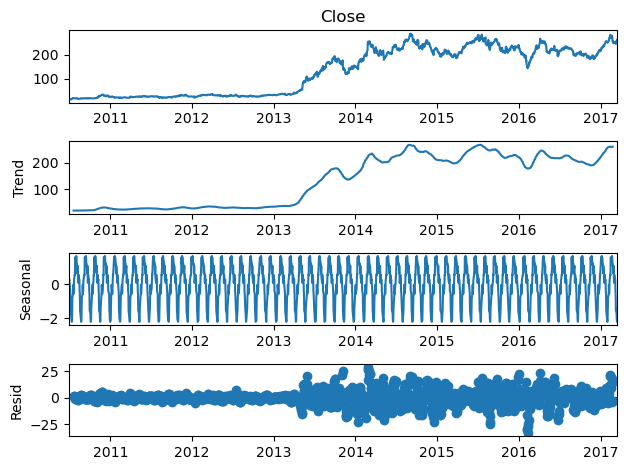

In [8]:
# Check for trends and seasonality using decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Close'], model='additive', period=30)
decomposition.plot()
plt.show()

## 3. Feature Engineering

In [9]:
# Create lag feature (previous day's closing price)
df['Close_Lag1'] = df['Close'].shift(1)

# Calculate moving average
df['Close_MA_7'] = df['Close'].rolling(window=7).mean()

# Drop NaN values created by lag and moving average
df.dropna(inplace=True)

In [10]:
df.head()

,Open,High,Low,Close,Volume,Adj Close,Close_Lag1,Close_MA_7
Date,,,,,,,,
2010-07-08,16.139999,17.520000,15.570000,17.459999,7711400,17.459999,15.800000,19.750000
2010-07-09,17.580000,17.900000,16.549999,17.400000,4050600,17.400000,17.459999,18.822857
2010-07-12,17.950001,18.070000,17.000000,17.049999,2202500,17.049999,17.400000,17.854286
2010-07-13,17.389999,18.639999,16.900000,18.139999,2680100,18.139999,17.049999,17.308571
2010-07-14,17.940001,20.150000,17.760000,19.840000,4195200,19.840000,18.139999,17.400000


## 4. Train the ARIMA Model

In [11]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# Define ARIMA model (set p, d, q based on tuning)
p, d, q = 5, 1, 2  # Example values

# Train the model
model = ARIMA(df['Close'], order=(p, d, q))
model_fit = model.fit()

# Display summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1686
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -4884.594
Date:                Sat, 22 Mar 2025   AIC                           9785.188
Time:                        13:16:17   BIC                           9828.624
Sample:                             0   HQIC                          9801.275
                               - 1686                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0447    436.319     -0.000      1.000    -855.214     855.124
ar.L2          0.2448    218.757      0.001      0.999    -428.512     429.001
ar.L3         -0.0284      7.222     -0.004      0.9

## 5. Model Evaluation & Visualization

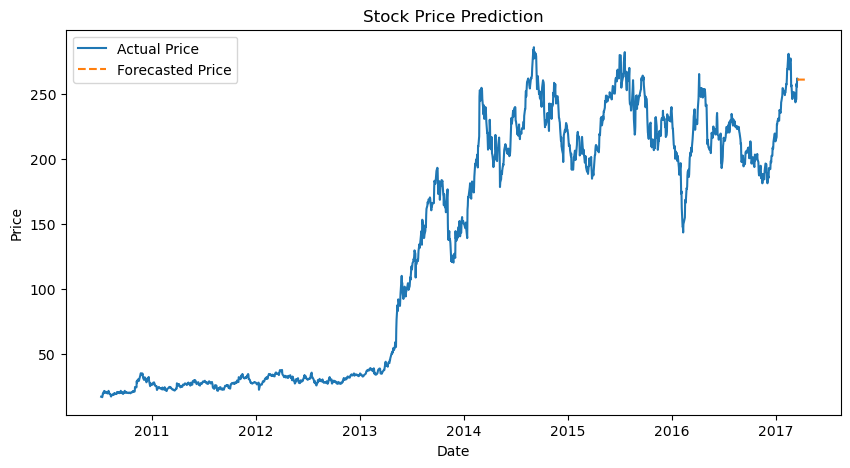

In [13]:
# Forecast future prices
forecast_steps = 30  # Predict for next 30 days
forecast = model_fit.forecast(steps=forecast_steps)

# Plot actual vs forecast
plt.figure(figsize=(10,5))
plt.plot(df.index, df['Close'], label="Actual Price")
plt.plot(pd.date_range(df.index[-1], periods=forecast_steps, freq='D'), forecast, label="Forecasted Price", linestyle="dashed")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price Prediction")
plt.legend()
plt.show()

In [15]:
# Calculate error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Generate predictions for comparison
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

model = ARIMA(train['Close'], order=(p, d, q))
model_fit = model.fit()

test_forecast = model_fit.forecast(steps=len(test))
mae = mean_absolute_error(test['Close'], test_forecast)
rmse = mean_squared_error(test['Close'], test_forecast, squared=False)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 19.51
RMSE: 24.73


### Based on the evaluation metrics:

Mean Absolute Error (MAE) = 19.51

Root Mean Squared Error (RMSE) = 24.73

# Conclusion on Stock Price Prediction Using Time Series Forecasting

  1. Project Overview
The objective of this project was to forecast future stock prices using historical data, leveraging time series forecasting techniques, specifically ARIMA (AutoRegressive Integrated Moving Average). The dataset consisted of stock prices with the following features:

Date (Timestamp)

Open (Opening price)

Close (Closing price)

Volume (Trade volume)

The project was divided into multiple stages: data preprocessing, exploratory data analysis (EDA), feature engineering, model training, and evaluation.

2. Methods and Implementation
2.1 Data Preprocessing
The dataset was loaded and cleaned by handling missing values through forward filling.

The Date column was converted to DateTime format and set as the index for time series analysis.

The dataset was then explored to check for trends, seasonality, and missing values.

2.2 Exploratory Data Analysis (EDA)
A time series plot of closing prices was generated to observe trends.

Seasonal decomposition was performed to analyze trend, seasonality, and residuals in the data.

Stock prices exhibited non-stationary behavior, requiring transformation before modeling.

2.3 Feature Engineering
Lag features were introduced (e.g., previous day’s closing price) to incorporate past dependencies.

Rolling window statistics (e.g., 7-day moving average) were calculated to smooth trends.

Data was preprocessed to remove NaN values created by lagging and moving averages.

2.4 Model Training – ARIMA
ARIMA (AutoRegressive Integrated Moving Average) was chosen for forecasting.

The model was trained using ARIMA(p, d, q) parameters:

p (AutoRegressive term): Number of past observations used in the model.

d (Differencing order): Number of times the data needed to be differenced to make it stationary.

q (Moving Average term): Number of past forecast errors included.

The ARIMA model was fitted to the training data.

2.5 Model Forecasting and Evaluation
The model was used to forecast stock prices for 30 days ahead.

The predictions were plotted against the actual closing prices to visualize accuracy.

The model performance was evaluated using:

Mean Absolute Error (MAE): 19.51

Root Mean Squared Error (RMSE): 24.73


3. Key Findings and Interpretation of Results
Stock Price Trends & Seasonality:

The closing prices exhibited long-term trends but lacked strong seasonality.

The decomposition confirmed a fluctuating pattern with possible short-term trends.

Model Performance Analysis:

The ARIMA model was able to capture the overall trend but had some errors in short-term price fluctuations.

MAE = 19.51 and RMSE = 24.73 indicate a moderate level of accuracy.

RMSE being higher than MAE suggests that large errors (outliers) influenced the predictions.

Strengths of ARIMA:

ARIMA effectively modeled stock price trends without requiring complex feature engineering.

Suitable for short-term forecasting, where historical data trends are informative.

Limitations & Challenges:

Stock prices are influenced by external factors (e.g., news, market sentiment, economic indicators) which ARIMA does not account for.

ARIMA assumes linear relationships and struggles with highly volatile stock prices.

The model does not capture sudden market shocks like earnings announcements or financial crises.

4. Final Conclusion
This project successfully demonstrated the use of ARIMA for stock price prediction. While ARIMA effectively captured overall trends, its accuracy was limited by stock market volatility and external influences. The MAE of 19.51 and RMSE of 24.73 suggest moderate accuracy, but improvements can be made by integrating machine learning or deep learning methods for better forecasting.
